In [2]:
# Load required libraries 
import numpy as np
from matplotlib import pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RationalQuadratic, Exponentiation, ExpSineSquared, WhiteKernel
import seaborn as sns

In [3]:
# Define the GPR function
def GPR_Model(X, y, training_indices, well_number, color):
    """
    Fits a Gaussian Process Regressor on data and returns the mean and standard deviation of predictions
    :param X: 1D vector containing the x values of observed data (e.g. months)
    :param y: 1D vector containing the y values of observed data (e.g. steam flow)
    :param training_indices: The indices of observations to train on.
    :param well_number: The number of the well being modeled (for labeling purposes)
    :param color: The color for the plot of this well's data
    :return: mean_prediction, std_prediction
    """
    X_train, y_train = X[training_indices], y[training_indices]

    kernel = Exponentiation(25**2*RationalQuadratic(length_scale=25), exponent=2)
    gaussian_process = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, alpha=1e-10)

    gaussian_process.fit(X_train, y_train)

    mean_prediction, std_prediction = gaussian_process.predict(X, return_std=True)

    cov_matrix = compute_covariance_matrix(kernel, X_train)

    plt.scatter(X_train, y_train, label=f"Training Observations Well {well_number}", color=color)
    return mean_prediction, std_prediction, cov_matrix

In [43]:
# Define the GPR function using the ORIGINAL KERNEL
def GPR_Model_ORIGINAL(X, y, training_indices, well_number, color):
    """
    Fits a Gaussian Process Regressor on data and returns the mean and standard deviation of predictions
    :param X: 1D vector containing the x values of observed data (e.g. months)
    :param y: 1D vector containing the y values of observed data (e.g. steam flow)
    :param training_indices: The indices of observations to train on.
    :param well_number: The number of the well being modeled (for labeling purposes)
    :param color: The color for the plot of this well's data
    :return: mean_prediction, std_prediction
    """
    X_train, y_train = X[training_indices], y[training_indices]

    kernel = Exponentiation(RationalQuadratic(), exponent=2)
    gaussian_process = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, alpha=1e-10)

    gaussian_process.fit(X_train, y_train)

    mean_prediction, std_prediction = gaussian_process.predict(X, return_std=True)

    plt.scatter(X_train, y_train, label=f"Training Observations Well {well_number}", color=color)
    return mean_prediction, std_prediction

In [4]:
# Define the covariance matrix function
def compute_covariance_matrix(kernel, X_train):
    """
    Computes the covariance matrix for the training points using the specified kernel.
    :param kernel: The kernel used in the Gaussian Process.
    :param X_train: The training data points.
    :return: Covariance matrix.
    """
    # Compute the covariance matrix
    K = kernel(X_train)
    return K

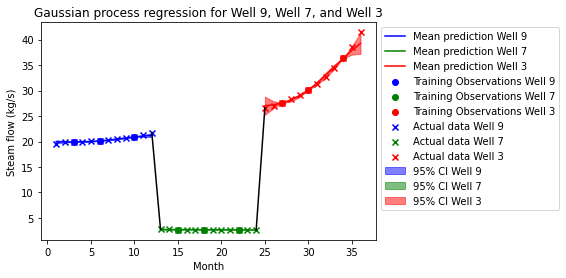

In [25]:
# The main script is ran from here
# The script fits a GPR on each well and subsequently 

months_well9 = np.linspace(start=1, stop=12, num=12).reshape(-1, 1)
months_well7 = np.linspace(start=13, stop=24, num=12).reshape(-1, 1)
months_well3 = np.linspace(start=25, stop=36, num=12).reshape(-1, 1)

# Well 9 data
y_well9 = np.array([19.42, 19.94, 19.92, 19.96, 20.03, 20.13, 20.25, 20.42, 20.63, 20.9, 21.25, 21.76])
training_indices_well9 = np.array([2, 5, 9])  # Define training indices for well 9

# Well 7 data
y_well7 = np.array([2.77, 2.74, 2.72, 2.71, 2.7, 2.69, 2.68, 2.67, 2.66, 2.66, 2.65, 2.65])
training_indices_well7 = np.array([2, 5, 9])  # Define training indices for well 7

# Well 3 data
y_well3 = np.array([26.64, 27, 27.57, 28.26, 29.1, 30.11, 31.31, 32.75, 34.4, 36.32, 38.59, 41.45])
training_indices_well3 = np.array([2, 5, 9])

# Combine y values
y_combined = np.concatenate((y_well9, y_well7, y_well3))

# Fit and plot GPR for well 9
mean_prediction_well9, std_prediction_well9, cov_matrix9 = GPR_Model(months_well9, y_well9, training_indices_well9, 9, 'blue')

# Fit and plot GPR for well 7
mean_prediction_well7, std_prediction_well7, cov_matrix7 = GPR_Model(months_well7, y_well7, training_indices_well7, 7, 'green')

# Fit and plot GPR for well 3
mean_prediction_well3, std_prediction_well3, cov_matrix3 = GPR_Model(months_well3, y_well3, training_indices_well3, 3, 'red')

# Plot actual data
plt.scatter(months_well9, y_well9, label="Actual data Well 9", color='blue', marker='x')
plt.scatter(months_well7, y_well7, label="Actual data Well 7", color='green', marker='x')
plt.scatter(months_well3, y_well3, label="Actual data Well 3", color='red', marker='x')

# Plot predictions for well 9
plt.plot(months_well9, mean_prediction_well9, label="Mean prediction Well 9", color='blue')
plt.fill_between(
    months_well9.ravel(),
    mean_prediction_well9 - 2 * std_prediction_well9,
    mean_prediction_well9 + 2 * std_prediction_well9,
    alpha=0.5,
    color='blue',
    label="95% CI Well 9"
)

# Plot predictions for well 7
plt.plot(months_well7, mean_prediction_well7, label="Mean prediction Well 7", color='green')
plt.fill_between(
    months_well7.ravel(),
    mean_prediction_well7 - 2 * std_prediction_well7,
    mean_prediction_well7 + 2 * std_prediction_well7,
    alpha=0.5,
    color='green',
    label="95% CI Well 7"
)

# Plot predictions for well 3
plt.plot(months_well3, mean_prediction_well3, label="Mean prediction Well 3", color='red')
plt.fill_between(
    months_well3.ravel(),
    mean_prediction_well3 - 2 * std_prediction_well3,
    mean_prediction_well3 + 2 * std_prediction_well3,
    alpha=0.5,
    color='red',
    label="95% CI Well 3"
)

# Connect the final point of well 9 with the first point of well 7 with a straight black line
plt.plot([months_well9[-1], months_well7[0]], [y_well9[-1], y_well7[0]], color="black")
plt.plot([months_well7[-1], months_well3[0]], [y_well7[-1], y_well3[0]], color="black")

# Finalize the plot
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.xlabel("Month")
plt.ylabel("Steam flow (kg/s)")
plt.title("Gaussian process regression for Well 9, Well 7, and Well 3")
plt.show()

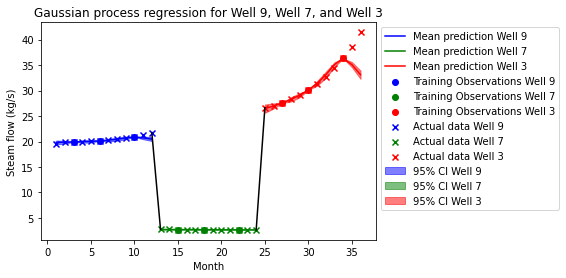

In [45]:
# Generate the predictions using the ORIGINAL KERNEL
# Fit and plot GPR for well 9
MPO9, SPO9 = GPR_Model_ORIGINAL(months_well9, y_well9, training_indices_well9, 9, 'blue')

# Fit and plot GPR for well 7
MPO7, SPO7 = GPR_Model_ORIGINAL(months_well7, y_well7, training_indices_well7, 7, 'green')

# Fit and plot GPR for well 3
MPO3, SPO3 = GPR_Model_ORIGINAL(months_well3, y_well3, training_indices_well3, 3, 'red')

# Plot actual data
plt.scatter(months_well9, y_well9, label="Actual data Well 9", color='blue', marker='x')
plt.scatter(months_well7, y_well7, label="Actual data Well 7", color='green', marker='x')
plt.scatter(months_well3, y_well3, label="Actual data Well 3", color='red', marker='x')

# Plot predictions for well 9
plt.plot(months_well9, MPO9, label="Mean prediction Well 9", color='blue')
plt.fill_between(
    months_well9.ravel(),
    MPO9 - 2 * SPO9,
    MPO9 + 2 * SPO9,
    alpha=0.5,
    color='blue',
    label="95% CI Well 9"
)

# Plot predictions for well 7
plt.plot(months_well7, MPO7, label="Mean prediction Well 7", color='green')
plt.fill_between(
    months_well7.ravel(),
    MPO7 - 2 * SPO7,
    MPO7 + 2 * SPO7,
    alpha=0.5,
    color='green',
    label="95% CI Well 7"
)

# Plot predictions for well 3
plt.plot(months_well3, MPO3, label="Mean prediction Well 3", color='red')
plt.fill_between(
    months_well3.ravel(),
    MPO3 - 2 * SPO3,
    MPO3 + 2 * SPO3,
    alpha=0.5,
    color='red',
    label="95% CI Well 3"
)

# Connect the final point of well 9 with the first point of well 7 with a straight black line
plt.plot([months_well9[-1], months_well7[0]], [y_well9[-1], y_well7[0]], color="black")
plt.plot([months_well7[-1], months_well3[0]], [y_well7[-1], y_well3[0]], color="black")

# Finalize the plot
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.xlabel("Month")
plt.ylabel("Steam flow (kg/s)")
plt.title("Gaussian process regression for Well 9, Well 7, and Well 3")
plt.show()


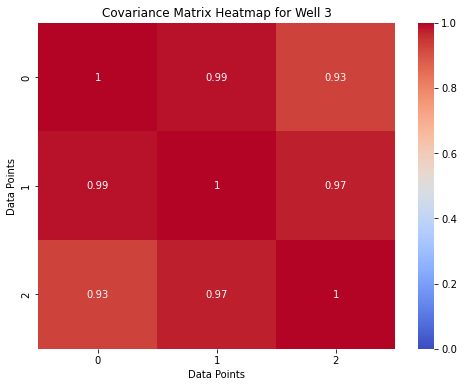

In [8]:
# The covariance matrices for each set of data is shown. This is using the updated kernel.
cov_matrix_3 = cov_matrix3/cov_matrix3[0][0]

# Create a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cov_matrix_3, annot=True, cmap='coolwarm', vmin=0, vmax=1)

# Adding labels and title
plt.title('Covariance Matrix Heatmap for Well 3')
plt.xlabel('Data Points')
plt.ylabel('Data Points')

# Show the plot
plt.show()

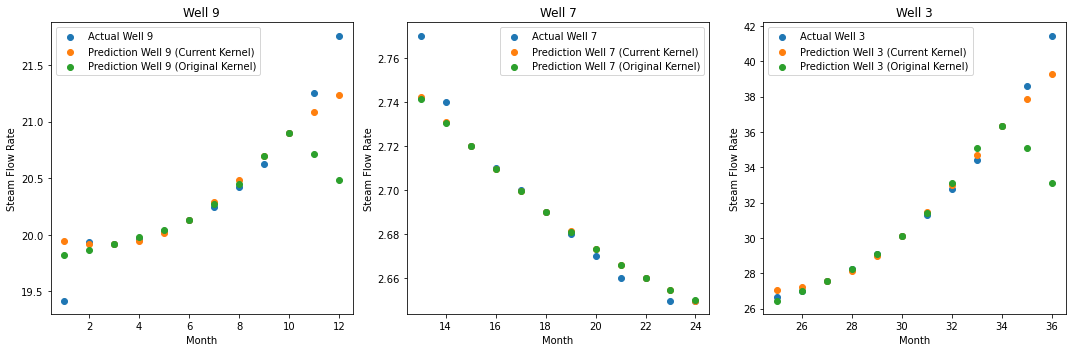

In [47]:
# Create a figure and a set of subplots showing actual data against predictions
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

# Plot for well 9
axs[0].scatter(months_well9, y_well9, label='Actual Well 9')
axs[0].scatter(months_well9, mean_prediction_well9, label='Prediction Well 9 (Current Kernel)')
axs[0].scatter(months_well9, MPO9, label='Prediction Well 9 (Original Kernel)')
axs[0].set_xlabel('Month')
axs[0].set_ylabel('Steam Flow Rate')
axs[0].set_title('Well 9')
axs[0].legend()

# Plot for well 7
axs[1].scatter(months_well7, y_well7, label='Actual Well 7')
axs[1].scatter(months_well7, mean_prediction_well7, label='Prediction Well 7 (Current Kernel)')
axs[1].scatter(months_well7, MPO7, label='Prediction Well 7 (Original Kernel)')
axs[1].set_xlabel('Month')
axs[1].set_ylabel('Steam Flow Rate')
axs[1].set_title('Well 7')
axs[1].legend()

# Plot for well 3
axs[2].scatter(months_well3, y_well3, label='Actual Well 3')
axs[2].scatter(months_well3, mean_prediction_well3, label='Prediction Well 3 (Current Kernel)')
axs[2].scatter(months_well3, MPO3, label='Prediction Well 3 (Original Kernel)')
axs[2].set_xlabel('Month')
axs[2].set_ylabel('Steam Flow Rate')
axs[2].set_title('Well 3')
axs[2].legend()

# Adjust layout
plt.tight_layout()

# Show plot
plt.show()

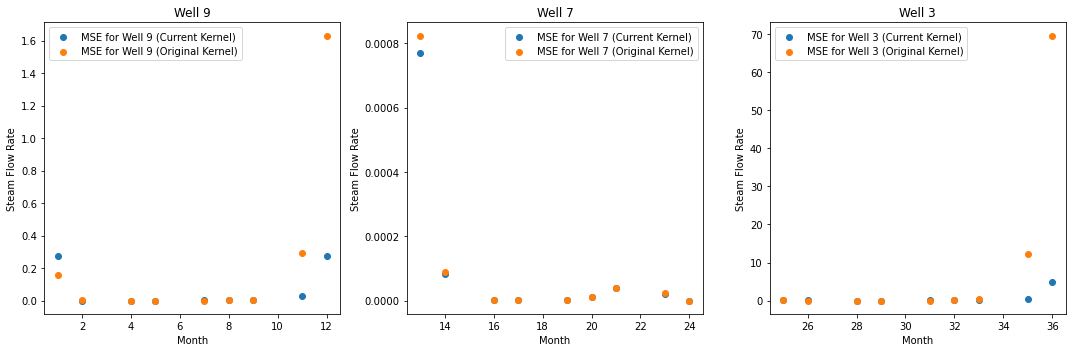

In [51]:
# Create a figure showing the MSE between data and predictions
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

# Plot for well 9
mask = np.ones(12, dtype=bool)

# Set the specified indices to False
mask[training_indices_well9] = False

axs[0].scatter(months_well9[mask], (y_well9[mask]-mean_prediction_well9[mask])**2, label='MSE for Well 9 (Current Kernel)')
axs[0].scatter(months_well9[mask], (y_well9[mask]-MPO9[mask])**2, label='MSE for Well 9 (Original Kernel)')
axs[0].set_xlabel('Month')
axs[0].set_ylabel('Steam Flow Rate')
axs[0].set_title('Well 9')
axs[0].legend()

# Plot for well 7
mask = np.ones(12, dtype=bool)

# Set the specified indices to False
mask[training_indices_well7] = False

axs[1].scatter(months_well7[mask], (y_well7[mask]-mean_prediction_well7[mask])**2, label='MSE for Well 7 (Current Kernel)')
axs[1].scatter(months_well7[mask], (y_well7[mask]-MPO7[mask])**2, label='MSE for Well 7 (Original Kernel)')
axs[1].set_xlabel('Month')
axs[1].set_ylabel('Steam Flow Rate')
axs[1].set_title('Well 7')
axs[1].legend()

# Plot for well 3
mask = np.ones(12, dtype=bool)

# Set the specified indices to False
mask[training_indices_well3] = False

axs[2].scatter(months_well3[mask], (y_well3[mask]-mean_prediction_well3[mask])**2, label='MSE for Well 3 (Current Kernel)')
axs[2].scatter(months_well3[mask], (y_well3[mask]-MPO3[mask])**2, label='MSE for Well 3 (Original Kernel)')
axs[2].set_xlabel('Month')
axs[2].set_ylabel('Steam Flow Rate')
axs[2].set_title('Well 3')
axs[2].legend()

# Adjust layout
plt.tight_layout()

# Show plot
plt.show()

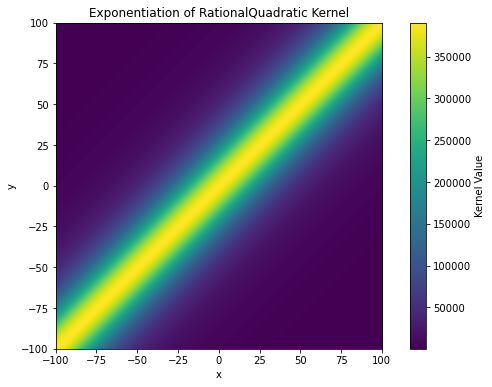

In [52]:
# Plot the current kernel function
# Define the kernel function
kernel = Exponentiation(25**2 * RationalQuadratic(length_scale=25), exponent=2)

# Generate a range of input values
x = np.linspace(-100, 100, 400)  # You can adjust the range and number of points

# Compute the kernel values
K = kernel(x[:, np.newaxis])

# Plot the kernel values
plt.figure(figsize=(10, 6))
plt.imshow(K, extent=(-100, 100, -100, 100), origin='lower')
plt.title('Exponentiation of RationalQuadratic Kernel')
plt.xlabel('x')
plt.ylabel('y')
plt.colorbar(label='Kernel Value')
plt.show()